In [1]:
from util.utils import get_som_labeled_img, check_ocr_box, get_caption_model_processor, get_yolo_model
import torch
from ultralytics import YOLO
from PIL import Image
device = 'mps'
model_path='weights/icon_detect/model.pt'

som_model = get_yolo_model(model_path)

som_model.to(device)
print('model to {}'.format(device))


model to mps


In [2]:
# two choices for caption model: fine-tuned blip2 or florence2
import importlib
# import util.utils
# importlib.reload(utils)
from util.utils import get_som_labeled_img, check_ocr_box, get_caption_model_processor, get_yolo_model

caption_model_processor = get_caption_model_processor(model_name="florence2", model_name_or_path="weights/icon_caption_florence", device=device)



Florence2LanguageForConditionalGeneration has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


In [3]:
som_model.device, type(som_model) 

(device(type='mps', index=0), ultralytics.models.yolo.model.YOLO)

In [ ]:
# reload utils
import importlib
import util.utils as utils
importlib.reload(utils)
# from utils import get_som_labeled_img, check_ocr_box, get_caption_model_processor, get_yolo_model


# image_path = 'imgs/google_page.png'
# image_path = 'imgs/windows_home.png'
# image_path = 'imgs/mac_home.png'
# image_path = 'imgs/mac_home_vs.png'

# image_path = 'imgs/windows_multitab.png'
# image_path = 'imgs/omni3.jpg'
# image_path = 'imgs/ios.png'
# image_path = 'imgs/word.png'
image_path = 'imgs/excel.png'


image = Image.open(image_path)
image_rgb = image.convert('RGB')
print('image size:', image.size)

box_overlay_ratio = max(image.size) / 3200
draw_bbox_config = {
    'text_scale': 0.8 * box_overlay_ratio,
    'text_thickness': max(int(2 * box_overlay_ratio), 1),
    'text_padding': max(int(3 * box_overlay_ratio), 1),
    'thickness': max(int(3 * box_overlay_ratio), 1),
}
BOX_TRESHOLD = 0.05

import time
start = time.time()
ocr_bbox_rslt, is_goal_filtered = check_ocr_box(image_path, display_img = False, output_bb_format='xyxy', goal_filtering=None, easyocr_args={'paragraph': False, 'text_threshold':0.9}, use_paddleocr=True)
text, ocr_bbox = ocr_bbox_rslt
cur_time_ocr = time.time() 

dino_labled_img, label_coordinates, parsed_content_list = get_som_labeled_img(image_path, som_model, BOX_TRESHOLD = BOX_TRESHOLD, output_coord_in_ratio=True, ocr_bbox=ocr_bbox,draw_bbox_config=draw_bbox_config, caption_model_processor=caption_model_processor, ocr_text=text,use_local_semantics=True, iou_threshold=0.7, scale_img=False, batch_size=128)
cur_time_caption = time.time() 



In [ ]:
# reload utils
import importlib
import util.utils as utils
importlib.reload(utils)
# from utils import get_som_labeled_img, check_ocr_box, get_caption_model_processor, get_yolo_model


# image_path = 'imgs/google_page.png'
# image_path = 'imgs/windows_home.png'
# image_path = 'imgs/mac_home.png'
# image_path = 'imgs/mac_home_vs.png'

# image_path = 'imgs/windows_multitab.png'
# image_path = 'imgs/omni3.jpg'
# image_path = 'imgs/ios.png'
# image_path = 'imgs/word.png'
image_path = 'imgs/excel.png'


image = Image.open(image_path)
image_rgb = image.convert('RGB')
print('image size:', image.size)

box_overlay_ratio = max(image.size) / 3200
draw_bbox_config = {
    'text_scale': 0.8 * box_overlay_ratio,
    'text_thickness': max(int(2 * box_overlay_ratio), 1),
    'text_padding': max(int(3 * box_overlay_ratio), 1),
    'thickness': max(int(3 * box_overlay_ratio), 1),
}
BOX_TRESHOLD = 0.05

import time
start = time.time()
ocr_bbox_rslt, is_goal_filtered = check_ocr_box(image_path, display_img = False, output_bb_format='xyxy', goal_filtering=None, easyocr_args={'paragraph': False, 'text_threshold':0.9}, use_paddleocr=True)
text, ocr_bbox = ocr_bbox_rslt
cur_time_ocr = time.time() 

dino_labled_img, label_coordinates, parsed_content_list = get_som_labeled_img(image_path, som_model, BOX_TRESHOLD = BOX_TRESHOLD, output_coord_in_ratio=True, ocr_bbox=ocr_bbox,draw_bbox_config=draw_bbox_config, caption_model_processor=caption_model_processor, ocr_text=text,use_local_semantics=True, iou_threshold=0.7, scale_img=False, batch_size=128)
cur_time_caption = time.time() 



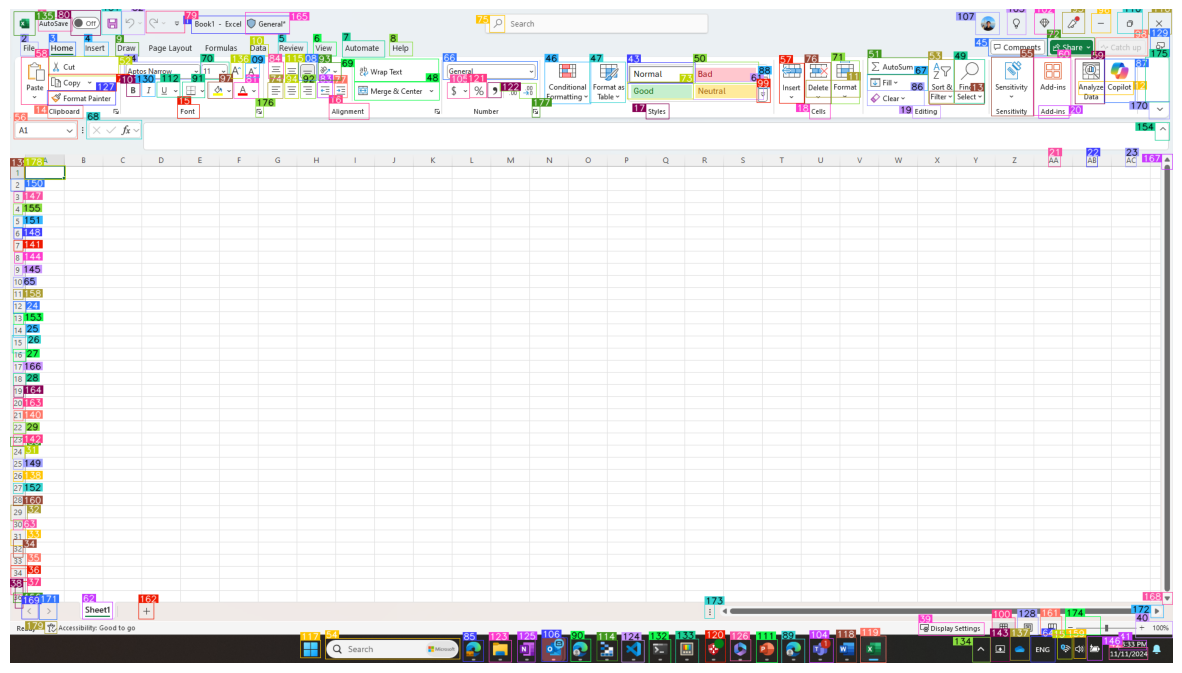

In [5]:
# plot dino_labled_img it is in base64
import base64
import matplotlib.pyplot as plt
import io
plt.figure(figsize=(15,15))

image = Image.open(io.BytesIO(base64.b64decode(dino_labled_img)))
plt.axis('off')

plt.imshow(image)
# print(len(parsed_content_list))


In [6]:
import pandas as pd
df = pd.DataFrame(parsed_content_list)
df['ID'] = range(len(df))

df

,type,bbox,interactivity,content,source,ID
0,text,"[0.023970818147063255, 0.012974976561963558, 0...",False,AutoSavee,box_ocr_content_ocr,0
1,text,"[0.15633141994476318, 0.011121409013867378, 0....",False,Book1 - Excel General*,box_ocr_content_ocr,1
2,text,"[0.009379885159432888, 0.05004633963108063, 0....",False,File,box_ocr_content_ocr,2
3,text,"[0.03335070237517357, 0.05004633963108063, 0.0...",False,Home,box_ocr_content_ocr,3
4,text,"[0.06357477605342865, 0.05004633963108063, 0.0...",False,Insert,box_ocr_content_ocr,4
...,...,...,...,...,...,...
175,icon,"[0.9762988686561584, 0.07390555739402771, 0.99...",True,a blank space or screen.,box_yolo_content_yolo,175
176,icon,"[0.21119704842567444, 0.14866754412651062, 0.2...",True,a profile or profile picture.,box_yolo_content_yolo,176
177,icon,"[0.4487318694591522, 0.14855234324932098, 0.45...",True,a profile or profile picture.,box_yolo_content_yolo,177
178,icon,"[0.012275636196136475, 0.23966358602046967, 0....",True,A blank space or screen.,box_yolo_content_yolo,178


In [7]:
parsed_content_list

[{'type': 'text',
  'bbox': [0.023970818147063255,
   0.012974976561963558,
   0.05315268412232399,
   0.033364225178956985],
  'interactivity': False,
  'content': 'AutoSavee',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.15633141994476318,
   0.011121409013867378,
   0.24075038731098175,
   0.037071362137794495],
  'interactivity': False,
  'content': 'Book1 - Excel  General*',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.009379885159432888,
   0.05004633963108063,
   0.023970818147063255,
   0.07136237621307373],
  'interactivity': False,
  'content': 'File',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.03335070237517357,
   0.05004633963108063,
   0.05627931281924248,
   0.07136237621307373],
  'interactivity': False,
  'content': 'Home',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.06357477605342865,
   0.05004633963108063,
   0.08441896736621857,
   0.07136237621307373],
  'interactivity': Fal